In [9]:
import glob
import numpy as np
import os

from qc import make_averaged_nii
from src import io
import matplotlib.pyplot as plt

In [17]:
# set main data path
base_data_path = "/Volumes/AhmedLab/princess/data"
exp = 1901

# set experiment file path
raw_path = glob.glob(os.path.join(base_data_path, 'raw', f'*{exp}'))[0]
print(raw_path)
nii_files = glob.glob(raw_path + '/*.nii')

for file in nii_files:
    print(os.path.basename(file))

/Volumes/AhmedLab/princess/data/raw/251024_1901
TSeries-10242025-1356-1901_channel_1.nii
TSeries-10242025-1356-1901_channel_2.nii


In [8]:
brain_images = io.load_nii(nii_files[1])
# takes ~1 min to load
print(os.path.basename(nii_files[1]), brain_images.shape)

TSeries-10242025-1356-1901_channel_2.nii (256, 175, 31, 1339)


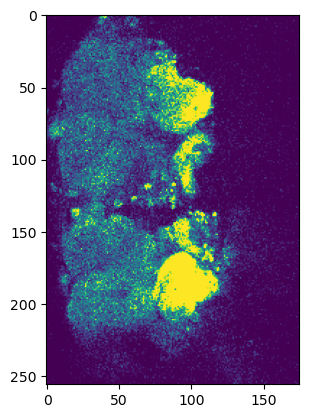

In [16]:
plt.imshow(brain_images[..., 15,10])
plt.imshow(brain_images[..., 4,10])

In [12]:
avg_brain_images = np.mean(brain_images, axis=2)
print(avg_brain_images.shape)

(256, 175, 1339)


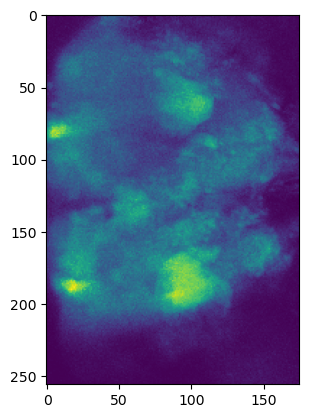

In [15]:
timepoint = [0,500, 700, 1000]
for time in timepoint:
    plt.imshow(avg_brain_images[..., time])

In [22]:
output_path = os.path.join(raw_path,f'{os.path.basename(nii_files[1][:-4])}_AVG.nii')

/Volumes/AhmedLab/princess/data/raw/251024_1901/TSeries-10242025-1356-1901_channel_2_AVG.nii


In [24]:
io.save_nii(output_path, avg_brain_images)

In [2]:
import qc

In [ ]:
path = '/Volumes/AhmedLab/princess/data/raw/TSeries_20251217-101'
qc.make_averaged_nii(path)